In [1]:
import train_model
import tensorflow as tf
from src.dataset import build_yolo_dataset
from src.model import build_model
import numpy as np

In [3]:
train_dataset1 = build_yolo_dataset()

In [4]:

train_dataset = (
    train_dataset1
    .map(
        lambda batch: (batch["image"], batch["targets"]),
        num_parallel_calls=tf.data.AUTOTUNE
    )
)

model = train_model.build_model()

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

loss_fn = train_model.YOLOLoss(
    lambda_box=5.0,
    lambda_obj=1.0,
    lambda_noobj=0.5,
    lambda_class=1.0,
)

history = train_model.train(
    model=model,
    optimizer=optimizer,
    train_dataset=train_dataset,
    loss_fn=loss_fn,
    epochs=3,
    steps_per_epoch=5,
    VERBOSE_STEPS=False,
)

Training on 358 batches per epoch

Epoch 1


Epoch 1:   1%|▏         | 5/358 [00:26<31:20,  5.33s/it, loss=113.51]  


----------------------------------------
Epoch 1 Summary
Average Total Loss : 164.58
Average Box Loss   : 25.49
Average Obj Loss   : 2.28
Average NoObj Loss : 55.53
Average Class Loss : 7.10
Learning rate: 1.00e-03
Epoch 1 completed in 26.63 seconds
Loss improved! Best model saved!

Epoch 2


Epoch 2:   1%|▏         | 5/358 [00:12<15:01,  2.55s/it, loss=134.65]


----------------------------------------
Epoch 2 Summary
Average Total Loss : 108.16
Average Box Loss   : 16.75
Average Obj Loss   : 3.94
Average NoObj Loss : 25.34
Average Class Loss : 7.82
Learning rate: 1.00e-03
Epoch 2 completed in 12.78 seconds
Loss improved! Best model saved!

Epoch 3


Epoch 3:   1%|▏         | 5/358 [00:15<17:44,  3.02s/it, loss=53.80]


----------------------------------------
Epoch 3 Summary
Average Total Loss : 58.47
Average Box Loss   : 7.81
Average Obj Loss   : 4.36
Average NoObj Loss : 16.00
Average Class Loss : 7.05
Learning rate: 1.00e-03
Epoch 3 completed in 15.08 seconds
Loss improved! Best model saved!
TRAINING COMPLETE!


In [1]:

import tensorflow as tf
from src.dataset import build_yolo_dataset
from src.model import build_model

model = build_model()
train_dataset = build_yolo_dataset()
train_dataset = (
    train_dataset
    .map(
        lambda batch: (batch["image"], batch["targets"]),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
)

batch = next(iter(train_dataset))

pred = model(batch[0])

print(batch[1].shape)
print(pred.shape)

(16, 7, 7, 2, 25)
(16, 7, 7, 2, 25)


In [6]:
print(train_dataset.element_spec)
batch = next(iter(train_dataset.take(1)))
print(type(batch), batch)

(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 7, 7, 2, 25), dtype=tf.float32, name=None))
<class 'tuple'> (<tf.Tensor: shape=(16, 224, 224, 3), dtype=float32, numpy=
array([[[[5.49554050e-01, 5.62596798e-01, 5.07431746e-01],
         [5.55190146e-01, 5.68671227e-01, 5.19063056e-01],
         [5.56716323e-01, 5.63596547e-01, 5.26895463e-01],
         ...,
         [1.44241348e-01, 1.49063379e-01, 1.11188151e-01],
         [1.40293106e-01, 1.51656523e-01, 1.14007026e-01],
         [1.42515048e-01, 1.48528934e-01, 1.08342044e-01]],

        [[5.60740590e-01, 5.56274176e-01, 5.16692996e-01],
         [5.65237403e-01, 5.75781226e-01, 5.11011600e-01],
         [5.53743005e-01, 5.69030166e-01, 5.15106797e-01],
         ...,
         [1.56946763e-01, 1.56946763e-01, 1.17818624e-01],
         [1.51713520e-01, 1.62845820e-01, 9.80829895e-02],
         [1.53502971e-01, 1.53502971e-01, 1.09542988e-01]],

        [[5.55207193e-01, 5.60581863e-01, 5.107

In [1]:
import json
def load_json(filepath):
    with open(filepath, "r") as f:
      return json.load(f)

In [2]:
history = load_json("history/history.json")

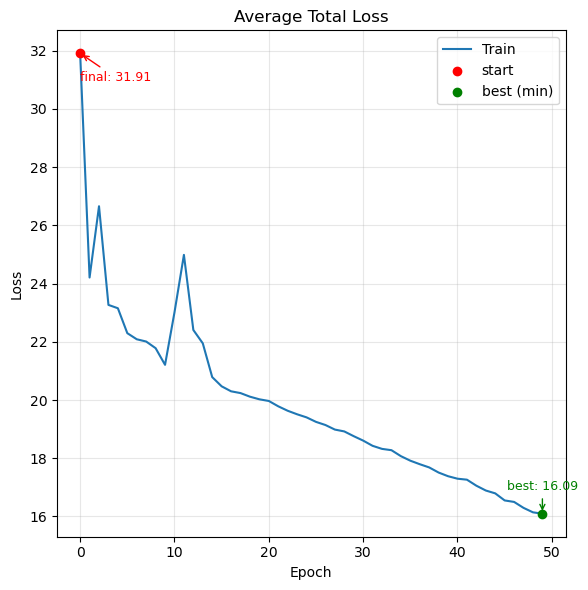

In [26]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1, figsize=(6,6))

plt.plot(history["loss"], label="Train")

plt.title("Average Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
#plt.legend()

start_loss = history["loss"][0]
x_start = 0

min_loss = min(history["loss"])
x_min = history["loss"].index(min_loss)

plt.scatter(x_start, start_loss, color="red", zorder=5, label="start")
plt.scatter(x_min, min_loss, color="green", zorder=5, label="best (min)")

plt.annotate(
    f"final: {start_loss:.2f}",
    xy=(x_start, start_loss),
    xytext=(x_start, start_loss*0.97),
    arrowprops=dict(arrowstyle="->", color="red"),
    ha="left",
    color="red",
    fontsize=9,
)
plt.annotate(
    f"best: {min_loss:.2f}",
    xy=(x_min, min_loss),
    #xytext=(x_min, min_loss * 0.95),
    xytext=(x_min, min_loss * 1.05),
    arrowprops=dict(arrowstyle="->", color="green"),
    ha="center",
    color="green",
    fontsize=9,
)

plt.legend()  # call after adding the scatter points so they appear in the legend

plt.tight_layout()
plt.savefig(
    "images/avg_total_loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [2]:
val_dataset = build_yolo_dataset(batch_size = 16, split="val")

In [3]:
for batch in val_dataset.take(1):
    images = batch["image"]
    true_boxes = batch["boxes"]
    true_labels = batch["labels"]

In [4]:
model = build_model()
checkpoint = tf.train.Checkpoint(model=model)
checkpoint.restore(
    "checkpoints/best_model-36"
).expect_partial()
preds = model(images, training=False)

In [5]:
preds.shape

TensorShape([16, 7, 7, 2, 25])

In [21]:
image = batch["image"][0]
pred = preds[0] 

In [22]:
tx = pred[..., 0]
ty = pred[..., 1]
tw = pred[..., 2]
th = pred[..., 3]
raw_objectness = pred[..., 4]
raw_class_logits = pred[..., 5:]

In [25]:
from src.constants import ANCHORS, GRID_SIZE

grid_h, grid_w = GRID_SIZE

detections = []

for cell_y in range(grid_h):
    for cell_x in range(grid_w):
        for anchor_idx in range(len(ANCHORS)):

            raw_objectness = pred[cell_y, cell_x, anchor_idx, 0]
            tx = pred[cell_y, cell_x, anchor_idx, 1]
            ty = pred[cell_y, cell_x, anchor_idx, 2]
            tw = pred[cell_y, cell_x, anchor_idx, 3]
            th = pred[cell_y, cell_x, anchor_idx, 4]
            raw_class_logits = pred[cell_y, cell_x, anchor_idx, 5:]

            # Decode center
            cx = (tx + cell_x) / grid_w
            cy = (ty + cell_y) / grid_h

            # Decode width/height
            anchor_w, anchor_h = ANCHORS[anchor_idx]

            bw = np.exp(tw) * anchor_w
            bh = np.exp(th) * anchor_h

            # Convert to corners
            xmin = cx - bw / 2
            ymin = cy - bh / 2
            xmax = cx + bw / 2
            ymax = cy + bh / 2

            # Convert normalized coordinates to pixels
            xmin *= 224
            ymin *= 224
            xmax *= 224
            ymax *= 224

            objectness = tf.sigmoid(raw_objectness)
            class_probs = tf.nn.softmax(raw_class_logits)

            class_id = np.argmax(class_probs)
            class_prob = class_probs[class_id]

            confidence = objectness * class_prob

            detections.append({
               "box": [
               float(xmin),
               float(ymin),
               float(xmax),
               float(ymax)
                 ],
              "objectness": float(objectness),
              "class_id": int(class_id),
              "class_prob": float(class_prob),
              "confidence": float(confidence),
             })

In [26]:
CONF_THRESHOLD = 0.05

filtered_detections = [
    d for d in detections
    if d["confidence"] >= CONF_THRESHOLD
]

print("Total predictions:", len(detections))
print("After confidence filtering:", len(filtered_detections))

for d in filtered_detections:
    d["box"] = [
        max(0, min(224, x))
        for x in d["box"]
    ]

Total predictions: 98
After confidence filtering: 2


In [27]:
print("tx range:", 
      float(tf.reduce_min(pred[..., 1])),
      float(tf.reduce_max(pred[..., 1])))

print("ty range:", 
      float(tf.reduce_min(pred[..., 2])),
      float(tf.reduce_max(pred[..., 2])))

print("tw range:", 
      float(tf.reduce_min(pred[..., 3])),
      float(tf.reduce_max(pred[..., 3])))

print("th range:", 
      float(tf.reduce_min(pred[..., 4])),
      float(tf.reduce_max(pred[..., 4])))

tx range: -0.007555536925792694 0.8367294073104858
ty range: 0.07066254317760468 0.9244716763496399
tw range: -1.0096300840377808 1.621141791343689
th range: -0.8286590576171875 1.9462826251983643


In [17]:
print("Objectness probability range:")

obj_probs = tf.sigmoid(pred[..., 0])

print(
    float(tf.reduce_min(obj_probs)),
    float(tf.reduce_max(obj_probs))
)

Objectness probability range:
0.00014237729192245752 0.4386720061302185


In [28]:
val_batch = next(iter(val_dataset))

In [29]:
images = val_batch["image"]
boxes = val_batch["boxes"]
labels = val_batch["labels"]
targets = val_batch["targets"]

In [30]:
print(images.shape)
print(boxes.shape)
print(labels.shape)
print(targets.shape)

(16, 224, 224, 3)
(16, 8, 4)
(16, 8)
(16, 7, 7, 2, 25)


In [31]:
preds = model(images, training=False)
pred = preds[0]
target = targets[0]

In [32]:
print("Ground-truth boxes:")
print(boxes[0].numpy())

print("\nGround-truth labels:")
print(labels[0].numpy())

Ground-truth boxes:
[[ 15.232       6.5706663 200.70401   175.01866  ]
 [  0.          0.          0.          0.       ]
 [  0.          0.          0.          0.       ]
 [  0.          0.          0.          0.       ]
 [  0.          0.          0.          0.       ]
 [  0.          0.          0.          0.       ]
 [  0.          0.          0.          0.       ]
 [  0.          0.          0.          0.       ]]

Ground-truth labels:
[19  0  0  0  0  0  0  0]


In [33]:
object_mask = target[..., 0]
positive_indices = tf.where(object_mask == 1)

print("Positive predictions:")
print(positive_indices.numpy())

Positive predictions:
[[2 3 1]]


In [34]:
for cell_y, cell_x, anchor_idx in positive_indices.numpy():

    true_values = target[
        cell_y, cell_x, anchor_idx, :5
    ]

    pred_values = pred[
        cell_y, cell_x, anchor_idx, :5
    ]

    print(f"\nCell=({cell_x}, {cell_y}), Anchor={anchor_idx}")

    print("Target:")
    print(true_values.numpy())

    print("Prediction:")
    print(pred_values.numpy())


Cell=(3, 2), Anchor=1
Target:
[1.         0.37400007 0.83733344 1.4206958  1.612101  ]
Prediction:
[-1.6073091  0.5518343  0.5220809  1.6211418  1.9462826]


In [35]:
for cell_y, cell_x, anchor_idx in positive_indices.numpy():

    true_values = target[cell_y, cell_x, anchor_idx, :5].numpy()
    pred_values = pred[cell_y, cell_x, anchor_idx, :5].numpy()

    pred_obj_prob = float(tf.sigmoid(pred_values[0]))

    print(f"\nCell=({cell_x}, {cell_y}), Anchor={anchor_idx}")

    print(f"  Objectness: {true_values[0]:.3f} -> "
          f"{pred_obj_prob:.3f}")

    print(f"  tx: {true_values[1]:.3f} -> "
          f"{pred_values[1]:.3f}")

    print(f"  ty: {true_values[2]:.3f} -> "
          f"{pred_values[2]:.3f}")

    print(f"  tw: {true_values[3]:.3f} -> "
          f"{pred_values[3]:.3f}")

    print(f"  th: {true_values[4]:.3f} -> "
          f"{pred_values[4]:.3f}")


Cell=(3, 2), Anchor=1
  Objectness: 1.000 -> 0.167
  tx: 0.374 -> 0.552
  ty: 0.837 -> 0.522
  tw: 1.421 -> 1.621
  th: 1.612 -> 1.946


In [36]:
for cell_y, cell_x, anchor_idx in positive_indices.numpy():

    true_class_logits = target[
        cell_y, cell_x, anchor_idx, 5:
    ]

    pred_class_logits = pred[
        cell_y, cell_x, anchor_idx, 5:
    ]

    true_class = int(tf.argmax(true_class_logits))
    pred_class_probs = tf.nn.softmax(pred_class_logits)
    pred_class = int(tf.argmax(pred_class_probs))
    pred_class_prob = float(pred_class_probs[pred_class])

    print(
        f"Cell=({cell_x},{cell_y}), Anchor={anchor_idx}: "
        f"true_class={true_class}, "
        f"pred_class={pred_class}, "
        f"pred_prob={pred_class_prob:.3f}"
    )

Cell=(3,2), Anchor=1: true_class=19, pred_class=19, pred_prob=0.518
